# Feature Selection -- Theory in Code, with scikit-learn
### Concepts Track -- Lecture 03

Companion notebook to the Feature Selection slides. Same housing-style dataset as Lecture 02, now
deliberately padded with **noise features** and a **near-duplicate** column, so every method below
has something concrete to catch -- and a wrong answer to avoid.

**session structure:**
1. Why bother -- building a dataset with known irrelevant and redundant features
2. Filter methods -- variance threshold, correlation with target, redundancy removal
3. Wrapper methods -- RFE and RFECV
4. Embedded methods -- Lasso and Random Forest importances
5. Comparing what each method actually kept
6. The leakage trap -- a concrete demonstration, not just a warning
7. Feature selection inside a proper `Pipeline`, evaluated honestly

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import (VarianceThreshold, SelectKBest, f_regression,
                                        RFE, RFECV, SelectFromModel)

sns.set_theme(style='whitegrid', context='notebook')
print('NumPy:', np.__version__, '| Pandas:', pd.__version__)

NumPy: 2.4.6 | Pandas: 3.0.5


In [2]:
from sklearn.datasets import load_wine

wine_data = load_wine()
wine_df = pd.DataFrame(
    data=wine_data.data,
    columns=wine_data.feature_names
)

wine_df['target'] = wine_data.target

wine_df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


     target           features  value
0         0            alcohol  14.23
1         0            alcohol  13.20
2         0            alcohol  13.16
3         0            alcohol  14.37
4         0            alcohol  13.24
..      ...                ...    ...
529       2  alcalinity_of_ash  20.50
530       2  alcalinity_of_ash  23.00
531       2  alcalinity_of_ash  20.00
532       2  alcalinity_of_ash  20.00
533       2  alcalinity_of_ash  24.50

[534 rows x 3 columns]


/Users/shakiba/Documents/quera/student_content/deep_learning_quera/venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 29.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/shakiba/Documents/quera/student_content/deep_learning_quera/venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 28.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/shakiba/Documents/quera/student_content/deep_learning_quera/venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 44.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/shakiba/Documents/quera/student_content/deep_learning_quera/venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 36.0% of th

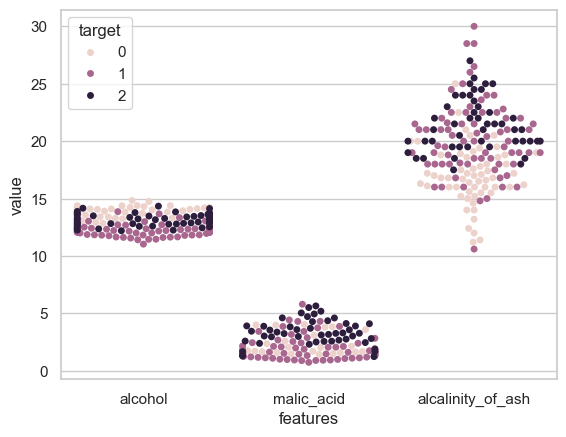

In [3]:
from seaborn import swarmplot

data_to_plot = pd.melt(wine_df[['alcohol', 'malic_acid', 'alcalinity_of_ash', 'target']],
                       id_vars='target',
                       var_name='features',
                       value_name='value')

print(data_to_plot)

swarmplot(data=data_to_plot, x='features', y='value', hue='target');

In [4]:
wine_df['target'].value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

<Axes: xlabel='target', ylabel='count'>

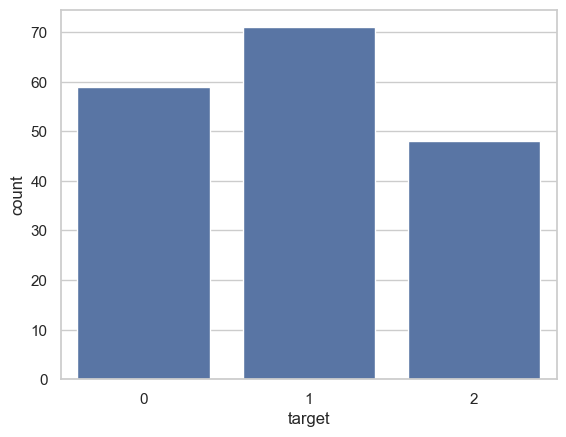

In [5]:
import seaborn as sns

sns.countplot(data=wine_df, x='target')

In [6]:
from sklearn.model_selection import train_test_split

X = wine_df.drop(['target'], axis=1)
y = wine_df['target']

X_train, X_test, y_train, y_test = train_test_split(X,
                                                   y,
                                                   test_size=0.3,
                                                   shuffle=True,
                                                   stratify=y,
                                                   random_state=42)

In [7]:
print(X_train.shape)
print(X_test.shape)

(124, 13)
(54, 13)


In [8]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score

# Initialize classifier
gbc = GradientBoostingClassifier(max_depth=5, random_state=42)

# Train classifier using all features
gbc.fit(X_train, y_train)

# Make predictions
preds = gbc.predict(X_test)

# Evaluate the model using the F1-score
f1_score_all = round(f1_score(y_test, preds, average='weighted'), 3)

print(f1_score_all)

0.908


In [9]:
X_train_v1, X_test_v1, y_tain_v1, y_test_v1 = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [10]:
X_train_v1.var(axis=0)

alcohol                             0.658341
malic_acid                          1.123507
ash                                 0.072433
alcalinity_of_ash                  11.471279
magnesium                         232.071532
total_phenols                       0.393226
flavanoids                          0.912299
nonflavanoid_phenols                0.013873
proanthocyanins                     0.335108
color_intensity                     5.669722
hue                                 0.052891
od280/od315_of_diluted_wines        0.470021
proline                         94906.710923
dtype: float64

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_X_train_v1 = scaler.fit_transform(X_train_v1)

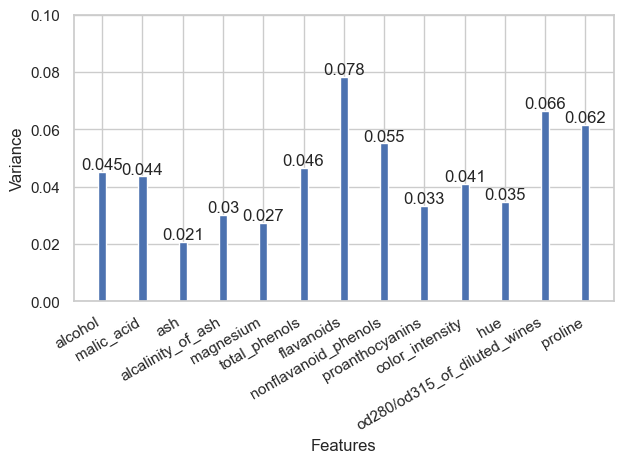

In [12]:
fig, ax = plt.subplots()

x = X.columns
y = scaled_X_train_v1.var(axis=0)

ax.bar(x, y, width=0.2)
ax.set_xlabel('Features')
ax.set_ylabel('Variance')
ax.set_ylim(0, 0.1)

for index, value in enumerate(y):
    plt.text(x=index, y=value+0.001, s=str(round(value, 3)), ha='center')
    
fig.autofmt_xdate()
plt.tight_layout()

In [13]:
sel_X_train_v1 = X_train_v1.drop(['ash', 'magnesium'], axis=1)
sel_X_test_v1 = X_test_v1.drop(['ash', 'magnesium'], axis=1)

gbc.fit(sel_X_train_v1, y_train)

var_preds = gbc.predict(sel_X_test_v1)

f1_score_var = round(f1_score(y_test_v1, var_preds, average='weighted'), 3)

print(f1_score_var)

0.963


In [14]:
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [15]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

f1_score_list = []

for k in range(1, 14):
    selector = SelectKBest(mutual_info_classif, k=k)
    selector.fit(X_train_v2, y_train_v2)
    
    sel_X_train_v2 = selector.transform(X_train_v2)
    sel_X_test_v2 = selector.transform(X_test_v2)
    
    gbc.fit(sel_X_train_v2, y_train_v2)
    kbest_preds = gbc.predict(sel_X_test_v2)
    
    f1_score_kbest = round(f1_score(y_test_v2, kbest_preds, average='weighted'), 3)
    
    f1_score_list.append(f1_score_kbest)

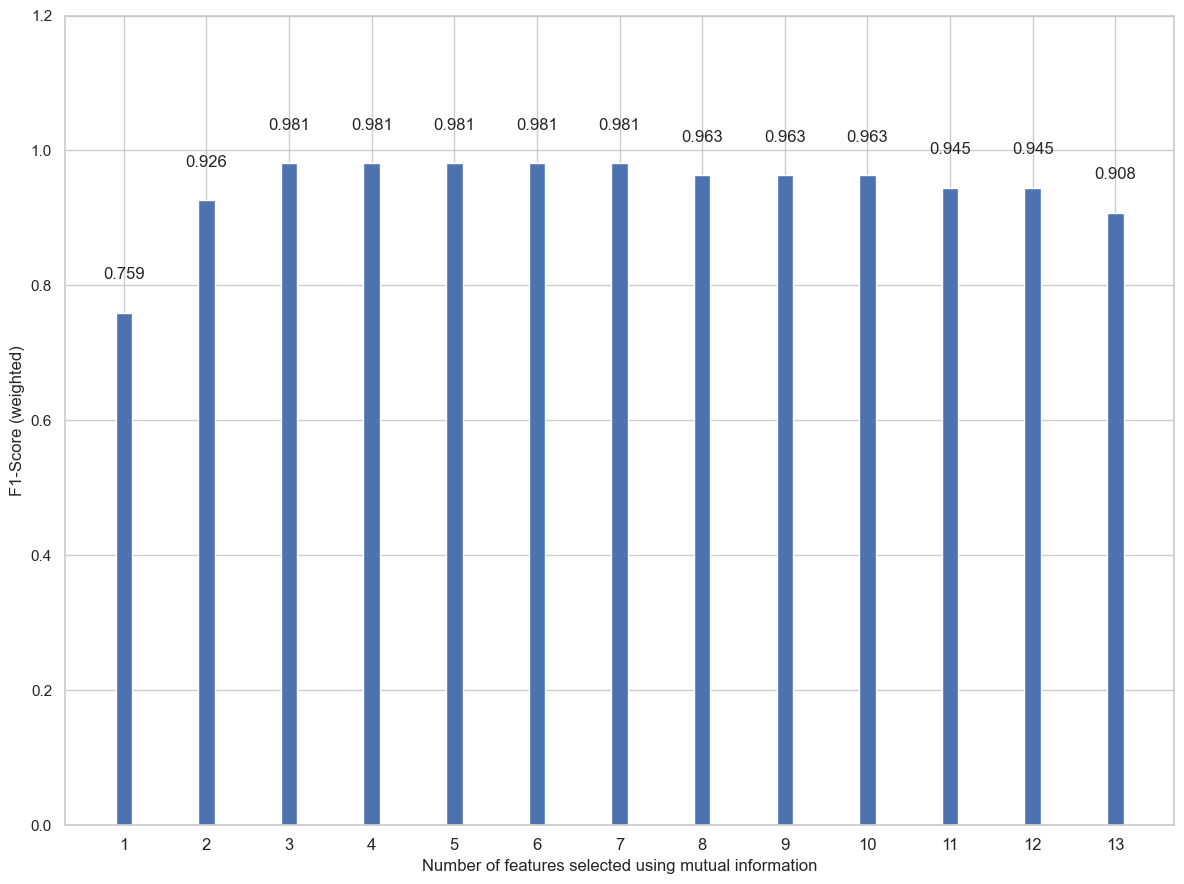

In [16]:
plt.rcParams["figure.figsize"] = (12,9)
fig, ax = plt.subplots()

x = np.arange(1, 14)
y = f1_score_list

ax.bar(x, y, width=0.2)
ax.set_xlabel('Number of features selected using mutual information')
ax.set_ylabel('F1-Score (weighted)')
ax.set_ylim(0, 1.2)
ax.set_xticks(np.arange(1, 14))
ax.set_xticklabels(np.arange(1, 14), fontsize=12)

for i, v in enumerate(y):
    plt.text(x=i+1, y=v+0.05, s=str(v), ha='center')
    
plt.tight_layout()

In [17]:
selector = SelectKBest(mutual_info_classif, k=3)
selector.fit(X_train_v2, y_train_v2)

selected_feature_mask = selector.get_support()

selected_features = X_train_v2.columns[selected_feature_mask]

selected_features

Index(['flavanoids', 'color_intensity', 'proline'], dtype='str')

In [18]:
X_train_v3, X_test_v3, y_train_v3, y_test_v3 = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [19]:
from sklearn.feature_selection import RFE

rfe_f1_score_list = []

for k in range(1, 14):
    RFE_selector = RFE(estimator=gbc, n_features_to_select=k, step=1)
    RFE_selector.fit(X_train_v3, y_train_v3)
    
    sel_X_train_v3 = RFE_selector.transform(X_train_v3)
    sel_X_test_v3 = RFE_selector.transform(X_test_v3)
    
    gbc.fit(sel_X_train_v3, y_train_v3)
    RFE_preds = gbc.predict(sel_X_test_v3)
    
    f1_score_rfe = round(f1_score(y_test_v3, RFE_preds, average='weighted'), 3)
    
    rfe_f1_score_list.append(f1_score_rfe)

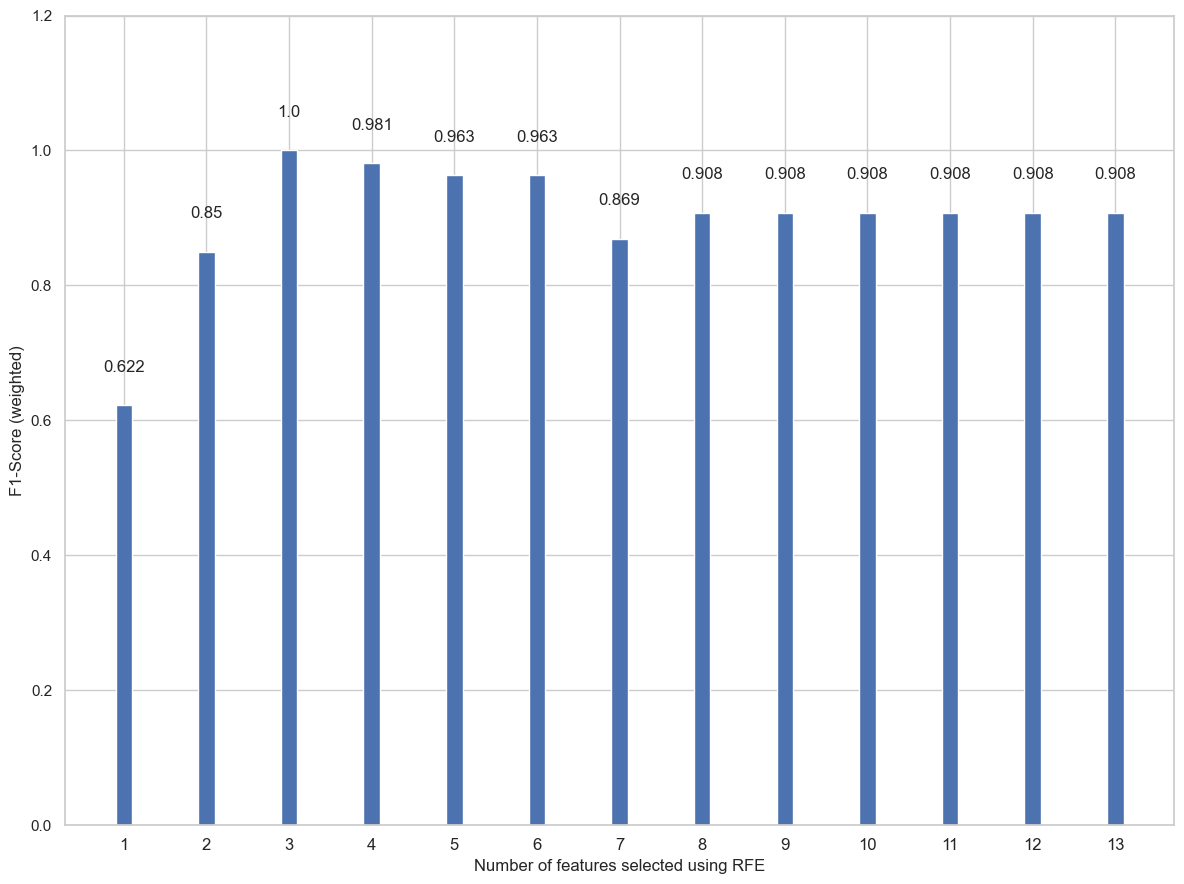

In [20]:
fig, ax = plt.subplots()

x = np.arange(1, 14)
y = rfe_f1_score_list

ax.bar(x, y, width=0.2)
ax.set_xlabel('Number of features selected using RFE')
ax.set_ylabel('F1-Score (weighted)')
ax.set_ylim(0, 1.2)
ax.set_xticks(np.arange(1, 14))
ax.set_xticklabels(np.arange(1, 14), fontsize=12)

for i, v in enumerate(y):
    plt.text(x=i+1, y=v+0.05, s=str(v), ha='center')
    
plt.tight_layout()

In [21]:
RFE_selector = RFE(estimator=gbc, n_features_to_select=3, step=10)
RFE_selector.fit(X_train_v3, y_train_v3)

selected_features_mask = RFE_selector.get_support()

selected_features = X_train_v3.columns[selected_features_mask]
selected_features

Index(['color_intensity', 'od280/od315_of_diluted_wines', 'proline'], dtype='str')

In [22]:
# boruta
# create shadow features: randomly shuffled version of each feature
# compute the importance of each shadow feature: the highest score becomes our threshold
# if the importance of the original feature is higher than the threshold: keep (otherwise discard)
X_train_v4, X_test_v4, y_train_v4, y_test_v4 = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [25]:
from boruta import BorutaPy

boruta_selector = BorutaPy(gbc, random_state=42)

boruta_selector.fit(X_train_v4.values, y_train_v4.values.ravel())

sel_X_train_v4 = boruta_selector.transform(X_train_v4.values)
sel_X_test_v4 = boruta_selector.transform(X_test_v4.values)

gbc.fit(sel_X_train_v4, y_train_v4)

boruta_preds = gbc.predict(sel_X_test_v4)

boruta_f1_score = round(f1_score(y_test_v4, boruta_preds, average='weighted'), 3)

In [26]:
selected_features_mask = boruta_selector.support_

selected_features = X_train_v4.columns[selected_features_mask]
selected_features

Index(['malic_acid', 'ash', 'magnesium', 'flavanoids', 'proanthocyanins',
       'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline'],
      dtype='str')

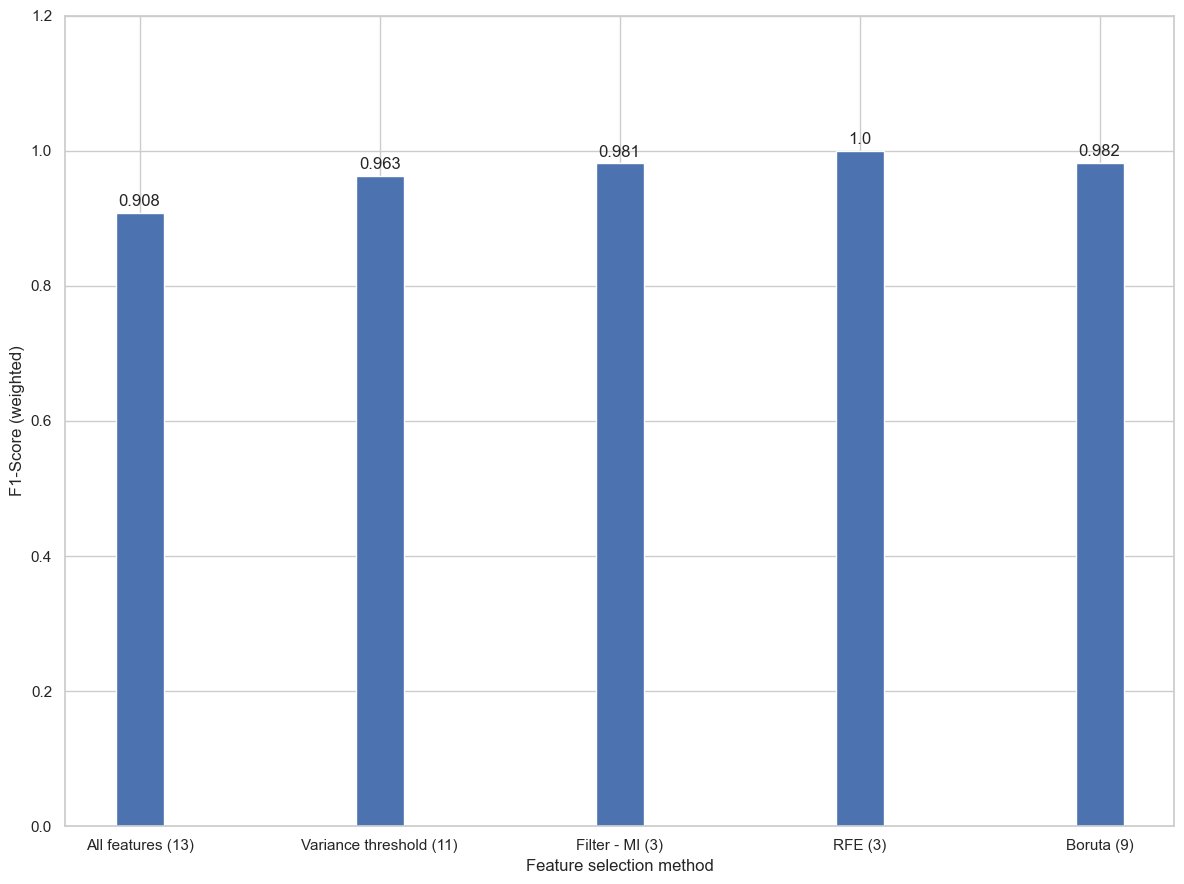

In [27]:
fig, ax = plt.subplots()

x = ['All features (13)', 'Variance threshold (11)', 'Filter - MI (3)', 'RFE (3)', 'Boruta (9)']
y = [f1_score_all, f1_score_var, 0.981, 1.0, boruta_f1_score]

ax.bar(x, y, width=0.2)
ax.set_xlabel('Feature selection method')
ax.set_ylabel('F1-Score (weighted)')
ax.set_ylim(0, 1.2)

for i, v in enumerate(y):
    plt.text(x=i, y=v+0.01, s=str(v), ha='center')
    
plt.tight_layout()

---
## Part 1 -- Why Bother: a Dataset With Known Irrelevant and Redundant Features

Same housing generator as Lecture 02 -- but this time we deliberately add 10 pure-noise columns
and one near-duplicate of `area_sqft`, so we know exactly what a "correct" feature selector
should throw away.

In [29]:
rng = np.random.default_rng(7)
n = 500

area_sqft = rng.normal(1800, 550, n).clip(450, 4200)
bedrooms = np.round(area_sqft / 650 + rng.normal(0, 0.6, n)).clip(1, 6).astype(int)
bathrooms = np.round(bedrooms * 0.75 + rng.normal(0, 0.5, n)).clip(1, 5).astype(int)
age_years = rng.uniform(0, 60, n)
distance_to_city_km = rng.exponential(8, n).clip(0.5, 45)
neighborhood = rng.choice(['Downtown', 'Suburb', 'Rural'], n, p=[0.3, 0.5, 0.2])
neighborhood_premium = np.select(
    [neighborhood == 'Downtown', neighborhood == 'Suburb'], [45000, 15000], default=0,
)

price = (
    120 * area_sqft + 8000 * bedrooms - 900 * age_years - 1500 * distance_to_city_km
    + neighborhood_premium + 20000 + rng.normal(0, 25000, n)
).clip(40000, None)

housing = pd.DataFrame({
    'area_sqft': area_sqft.round(0), 'bedrooms': bedrooms, 'bathrooms': bathrooms,
    'age_years': age_years.round(1), 'distance_to_city_km': distance_to_city_km.round(2),
    'neighborhood': neighborhood, 'price': price.round(0),
})

# A NEAR-DUPLICATE of area_sqft -- correlates almost perfectly, carries almost no NEW information.
housing['area_sqft_v2'] = housing['area_sqft'] + rng.normal(0, 30, n)

# A near-constant column -- 96% of houses have a garage, a textbook VarianceThreshold catch.
housing['has_garage'] = rng.choice([1, 0], n, p=[0.96, 0.04])

# TEN pure-noise features -- random numbers with NO relationship to price whatsoever.
for i in range(1, 11):
    housing[f'noise_{i}'] = rng.normal(0, 1, n)

print('Dataset ready:', housing.shape)
print('True signal:      area_sqft, bedrooms, bathrooms, age_years, distance_to_city_km, neighborhood')
print('Redundant:        area_sqft_v2 (near-duplicate of area_sqft)')
print('Near-constant:    has_garage')
print('Pure noise:       noise_1 ... noise_10')
housing.head()

Dataset ready: (500, 19)
True signal:      area_sqft, bedrooms, bathrooms, age_years, distance_to_city_km, neighborhood
Redundant:        area_sqft_v2 (near-duplicate of area_sqft)
Near-constant:    has_garage
Pure noise:       noise_1 ... noise_10


,area_sqft,bedrooms,bathrooms,age_years,distance_to_city_km,neighborhood,price,area_sqft_v2,has_garage,noise_1,noise_2,noise_3,noise_4,noise_5,noise_6,noise_7,noise_8,noise_9,noise_10
0,1801.0,3,2,41.3,0.50,Rural,201495.0,1814.120714,1,0.520690,1.228295,-0.104734,-0.943860,-0.878135,-0.031201,0.709593,1.010281,0.683597,0.883470
1,1964.0,2,2,27.1,20.30,Rural,186050.0,1965.842507,1,-1.441902,0.959887,-0.381320,-0.256356,1.048958,1.414473,0.665434,0.250573,-0.282951,1.477133
2,1649.0,2,1,11.3,4.48,Rural,203339.0,1676.421562,1,-1.239616,0.062734,2.153116,0.264235,0.715936,0.279134,-0.095929,0.543177,0.816345,-0.194531
3,1310.0,3,3,58.0,2.58,Rural,142117.0,1320.696267,1,-0.356582,0.609897,0.008462,-1.558858,-0.066577,0.122006,-0.776291,-0.495439,0.176025,-0.492075
4,1550.0,3,2,28.0,2.37,Suburb,209585.0,1530.957268,1,-0.765047,0.564602,-0.969960,1.481013,0.448264,-0.048360,-0.941989,0.794734,1.024222,1.599463


**Notice what this setup gives us that a real dataset never would:** ground truth. We *know*
`noise_1`..`noise_10` are irrelevant and `area_sqft_v2` is redundant, because we built them that
way. Every method below gets checked against that ground truth -- something you'd never have this
luxury of doing on a real project, which is exactly why it's worth doing once here.

---
## Part 2 -- Filter Methods

### 2.1 -- Variance Threshold: Catching the Near-Constant Column

In [30]:
numeric_cols = ['area_sqft', 'bedrooms', 'bathrooms', 'age_years', 'distance_to_city_km',
                 'area_sqft_v2', 'has_garage'] + [f'noise_{i}' for i in range(1, 11)]

print('Variance of each numeric column (unscaled):')
print(housing[numeric_cols].var().round(2).sort_values())

Variance of each numeric column (unscaled):
has_garage                  0.02
bathrooms                   0.73
noise_6                     0.88
noise_8                     0.93
noise_7                     0.93
noise_5                     0.93
noise_10                    0.96
noise_4                     0.96
noise_2                     0.97
bedrooms                    0.98
noise_3                     1.04
noise_1                     1.10
noise_9                     1.12
distance_to_city_km        69.27
age_years                 289.47
area_sqft              261695.89
area_sqft_v2           264423.55
dtype: float64


In [31]:
# VarianceThreshold works on a MATRIX of columns and reports which ones survive -- fitting it on
# a single below-threshold column has nothing left to keep, which sklearn treats as an error
# rather than a silent drop. Fit it on the full numeric set instead, the way it's actually used.
selector = VarianceThreshold(threshold=0.05)
selector.fit(housing[numeric_cols])
support = pd.Series(selector.get_support(), index=numeric_cols)

print(f"'has_garage' variance: {housing['has_garage'].var():.4f}")
print(f"Kept by VarianceThreshold(threshold=0.05)? {support['has_garage']}")
print()
print('Columns dropped entirely by this threshold:')
print(list(support[~support].index))

'has_garage' variance: 0.0216
Kept by VarianceThreshold(threshold=0.05)? False

Columns dropped entirely by this threshold:
['has_garage']


**A real caveat, worth stating plainly:** `has_garage` being low-variance doesn't automatically
mean it's useless for predicting price -- it just means almost every house shares the same value,
so it can't help *distinguish* one house's price from another's in this particular sample. That's
exactly the right reason to drop it, but it's a different reason than "irrelevant to price."

### 2.2 -- SelectKBest: Scoring Against the Target

            feature     f_score       p_value
          area_sqft 2002.387797 1.280537e-176
       area_sqft_v2 1996.176767 2.379476e-176
           bedrooms  631.803901  1.233042e-90
          bathrooms  221.055888  1.212020e-41
          age_years   25.063485  7.710979e-07
distance_to_city_km    9.189303  2.561095e-03
            noise_3    5.495694  1.945541e-02
            noise_7    3.864498  4.987311e-02
            noise_1    2.389637  1.227772e-01
            noise_8    1.694454  1.936167e-01
            noise_5    1.221827  2.695362e-01
            noise_2    0.824145  3.644101e-01
            noise_6    0.556236  4.561325e-01
            noise_9    0.370528  5.429941e-01
            noise_4    0.013555  9.073630e-01
           noise_10    0.000471  9.826957e-01


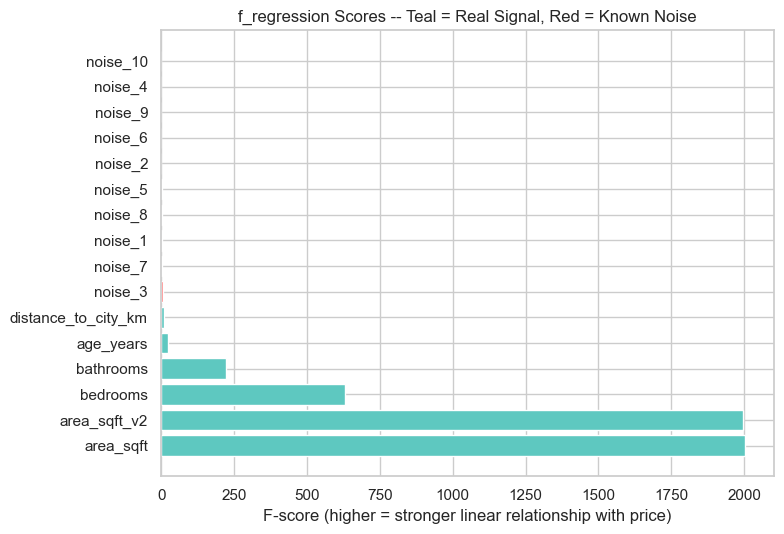

In [ ]:
numeric_features_only = ['area_sqft', 'bedrooms', 'bathrooms', 'age_years', 'distance_to_city_km',
                          'area_sqft_v2'] + [f'noise_{i}' for i in range(1, 11)]
X_numeric = housing[numeric_features_only]
y = housing['price']
# For each feature individually, f_regression:
# Computes its correlation with price.
# Fits a simple linear regression
# Calculates an F-statistic that measures how much the feature explains variation in the target relative to unexplained variation.
# Computes a p-value to test whether that relationship is statistically significant.
f_scores, p_values = f_regression(X_numeric, y)
score_df = pd.DataFrame({'feature': numeric_features_only, 'f_score': f_scores, 'p_value': p_values}) \
             .sort_values('f_score', ascending=False)
print(score_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = ['#5ec8c0' if 'noise' not in f else '#ff6b6b' for f in score_df['feature']]
ax.barh(score_df['feature'], score_df['f_score'], color=colors)
ax.set_xlabel('F-score (higher = stronger linear relationship with price)')
ax.set_title('f_regression Scores -- Teal = Real Signal, Red = Known Noise')
plt.tight_layout()
plt.show()

**Every noise feature lands near the bottom, exactly as it should** -- `f_regression` correctly
identifies that `noise_1`..`noise_10` have no real linear relationship to `price`. Notice
`area_sqft_v2` scores nearly as high as `area_sqft` itself -- which is *correct* (it really is
almost as predictive on its own), but is exactly the redundancy problem Part 2.3 exists to catch;
scoring against the target alone can't tell two redundant good features apart from two independently
useful ones.

### 2.3 -- Correlation-Based Redundancy Removal

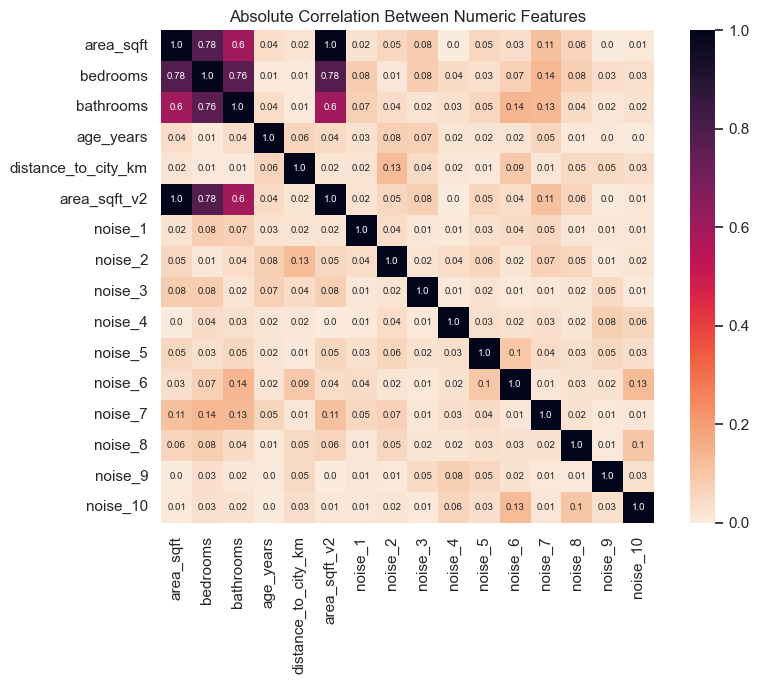

In [33]:
corr_matrix = X_numeric.corr().abs()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, cmap='rocket_r', vmin=0, vmax=1, ax=ax, square=True,
            annot=corr_matrix.round(2), fmt='', annot_kws={'size': 7})
ax.set_title('Absolute Correlation Between Numeric Features')
plt.tight_layout()
plt.show()

In [34]:
# Find pairs above a redundancy threshold, excluding the trivial self-correlation on the diagonal.
threshold = 0.9
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
redundant_pairs = [(col, row, upper.loc[row, col]) for col in upper.columns for row in upper.index
                    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > threshold]

print(f'Feature pairs correlated above {threshold}:')
for a, b, val in redundant_pairs:
    print(f'  {a}  <->  {b}   (r = {val:.3f})')

to_drop = [pair[1] for pair in redundant_pairs]   # drop the second of each redundant pair
print(f'\nDropping: {to_drop}')

Feature pairs correlated above 0.9:
  area_sqft_v2  <->  area_sqft   (r = 0.998)

Dropping: ['area_sqft']


**This is the direct, concrete version of Lecture 02's VIF discussion:** `area_sqft` and
`area_sqft_v2` correlate above 0.9 with each other, not just with price -- exactly the redundancy
VIF was designed to flag, caught here with nothing more than a correlation matrix and a threshold.

---
## Part 3 -- Wrapper Methods: RFE and RFECV

### 3.1 -- Preparing the Full Feature Set

In [35]:
all_features = ['area_sqft', 'bedrooms', 'bathrooms', 'age_years', 'distance_to_city_km',
                 'neighborhood', 'area_sqft_v2', 'has_garage'] + [f'noise_{i}' for i in range(1, 11)]
X = housing[all_features]
y = housing['price']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), [c for c in all_features if c != 'neighborhood']),
    ('cat', OneHotEncoder(drop='first'), ['neighborhood']),
])
X_transformed = preprocessor.fit_transform(X)
feature_names_full = ([c for c in all_features if c != 'neighborhood'] +
                       list(preprocessor.named_transformers_['cat'].get_feature_names_out(['neighborhood'])))
print(f'Total features after preprocessing: {len(feature_names_full)}')

Total features after preprocessing: 19


### 3.2 -- RFE: Ranking and Eliminating

In [36]:
rfe = RFE(estimator=LinearRegression(), n_features_to_select=6)
rfe.fit(X_transformed, y)

rfe_df = pd.DataFrame({'feature': feature_names_full, 'selected': rfe.support_, 'rank': rfe.ranking_}) \
            .sort_values('rank')
print(rfe_df.to_string(index=False))

            feature  selected  rank
          area_sqft      True     1
 neighborhood_Rural      True     1
       area_sqft_v2      True     1
neighborhood_Suburb      True     1
           bedrooms      True     1
          age_years      True     1
distance_to_city_km     False     2
            noise_9     False     3
          bathrooms     False     4
            noise_1     False     5
         has_garage     False     6
            noise_8     False     7
            noise_2     False     8
            noise_3     False     9
            noise_6     False    10
            noise_4     False    11
           noise_10     False    12
            noise_7     False    13
            noise_5     False    14


**Read this table against the ground truth carefully -- it's not the clean result you might
expect.** RFE correctly excluded every `noise_*` feature and `has_garage`. But look at which real
features it kept: it selected `area_sqft_v2` (the redundant duplicate) right alongside `area_sqft`,
while dropping two genuinely informative features, `bathrooms` and `distance_to_city_km`, to make
room. **This is RFE's own blind spot, and it's a direct consequence of multicollinearity:** when
two features carry almost identical information, a linear model can express the same fit by
splitting weight between them in many different ways, so which one keeps a non-zero coefficient
(and therefore survives elimination) is unstable -- small changes in the data could easily flip
which of `area_sqft` and `area_sqft_v2` "wins." **The lesson isn't that RFE is broken -- it's that
no single method here is immune to redundancy**, which is exactly why Part 2.3's correlation
filter is worth running as a first pass, before RFE, Lasso, or tree importances ever see the data.

### 3.3 -- RFECV: Let Cross-Validation Choose the Count

Optimal number of features found: 7


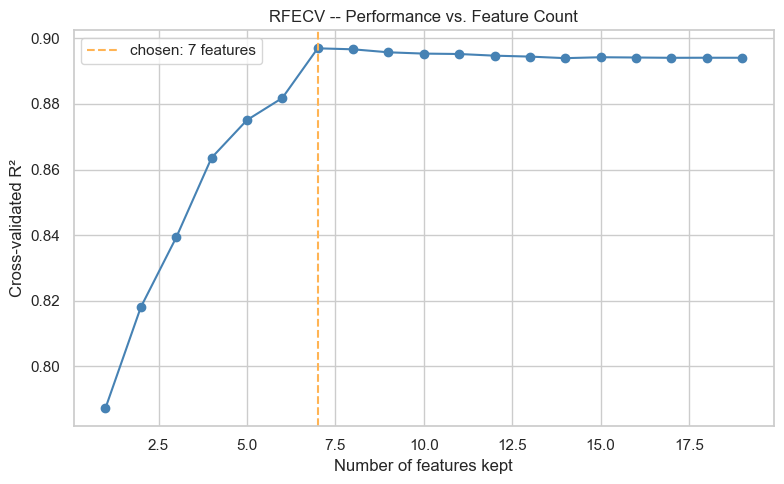

In [37]:
rfecv = RFECV(estimator=LinearRegression(), min_features_to_select=1, cv=KFold(5, shuffle=True, random_state=42),
              scoring='r2')
rfecv.fit(X_transformed, y)

print(f'Optimal number of features found: {rfecv.n_features_}')

fig, ax = plt.subplots(figsize=(8, 5))
n_scores = len(rfecv.cv_results_['mean_test_score'])
ax.plot(range(1, n_scores + 1), rfecv.cv_results_['mean_test_score'], marker='o', color='steelblue')
ax.axvline(rfecv.n_features_, color='#ffb454', linestyle='--', label=f'chosen: {rfecv.n_features_} features')
ax.set_xlabel('Number of features kept')
ax.set_ylabel('Cross-validated R²')
ax.set_title('RFECV -- Performance vs. Feature Count')
ax.legend()
plt.tight_layout()
plt.show()

**Read the curve, not just the chosen number.** Performance should rise sharply as the first few
truly informative features are added, then flatten into a plateau -- adding noise features beyond
that point doesn't meaningfully help, and may even slightly hurt. `RFECV` picks the best point on
this curve automatically, which is exactly the practical answer to the slides' "how many features
is enough" question.

---
## Part 4 -- Embedded Methods: Lasso and Random Forest

### 4.1 -- Lasso via SelectFromModel

In [38]:
lasso_selector = SelectFromModel(Lasso(alpha=5000, max_iter=20000))
lasso_selector.fit(X_transformed, y)

lasso_kept = np.array(feature_names_full)[lasso_selector.get_support()]
print(f'Lasso kept {len(lasso_kept)} of {len(feature_names_full)} features:')
print(list(lasso_kept))

Lasso kept 6 of 19 features:
[np.str_('area_sqft'), np.str_('bedrooms'), np.str_('age_years'), np.str_('distance_to_city_km'), np.str_('area_sqft_v2'), np.str_('neighborhood_Rural')]


**At this `alpha`, every single one of the 10 noise features gets zeroed out** -- a clean result,
worth contrasting with a weaker `alpha`. Try re-running with `alpha=500` and several noise
features survive; the right `alpha` isn't obvious in advance, it's found by tuning, exactly like
any other hyperparameter (Lecture 04's subject). One thing Lasso does **not** clean up here:
`area_sqft` and `area_sqft_v2` are both kept, still redundant with each other. Lasso is good at
recognizing "irrelevant" but not reliably at recognizing "duplicate" -- when two features are
highly correlated, Lasso doesn't consistently pick one and zero the other, it can keep both or
split weight between them almost arbitrarily. That's exactly why Part 2.3's correlation filter
is still worth doing even when you're also using Lasso.

### 4.2 -- Random Forest Importances via SelectFromModel

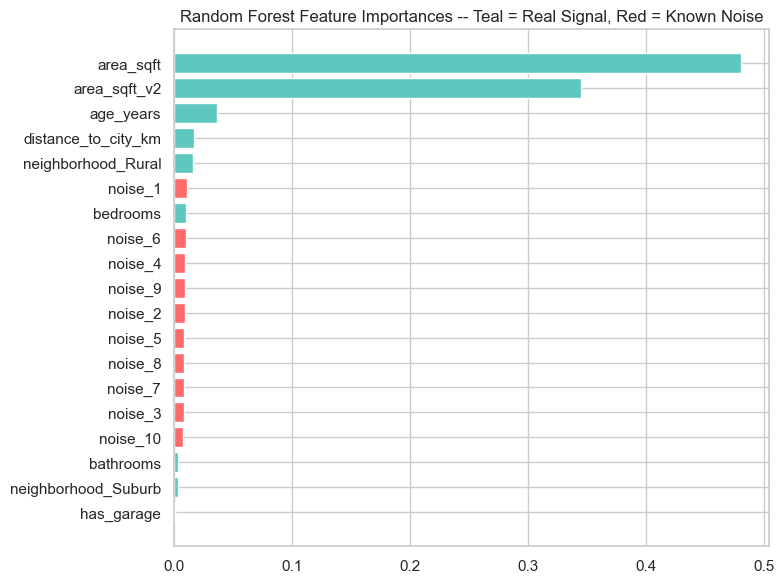

In [39]:
rf_selector = SelectFromModel(RandomForestRegressor(n_estimators=200, random_state=42))
rf_selector.fit(X_transformed, y)

importances = rf_selector.estimator_.feature_importances_
imp_df = pd.DataFrame({'feature': feature_names_full, 'importance': importances}) \
            .sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#5ec8c0' if 'noise' not in f else '#ff6b6b' for f in imp_df['feature']]
ax.barh(imp_df['feature'], imp_df['importance'], color=colors)
ax.invert_yaxis()
ax.set_title('Random Forest Feature Importances -- Teal = Real Signal, Red = Known Noise')
plt.tight_layout()
plt.show()

**Every `noise_*` feature does rank near the bottom, as expected -- but look closer at `bedrooms`
and `bathrooms`.** They rank barely above several noise features, even though we built them as
genuinely predictive of price. This is a real, well-known blind spot of tree importances, not a
bug: `area_sqft` and its near-duplicate `area_sqft_v2` are so dominant and so correlated with
`bedrooms`/`bathrooms` that the trees satisfy most of their splits using the area features alone,
"stealing" credit that would otherwise go to the correlated features. **Linear coefficients and
tree importances fail differently under multicollinearity** -- Lasso tends to keep or split
correlated features arbitrarily (previous section), while tree importances can systematically
under-credit a genuinely useful feature that's correlated with a stronger one. Neither failure
mode is visible from a single method alone, which is exactly why Part 5 compares several.

In [40]:
rf_kept = np.array(feature_names_full)[rf_selector.get_support()]
print(f'SelectFromModel (RF, default threshold="mean") kept {len(rf_kept)} features: {list(rf_kept)}')

SelectFromModel (RF, default threshold="mean") kept 2 features: [np.str_('area_sqft'), np.str_('area_sqft_v2')]


The default `"mean"` threshold turns out strict here -- `area_sqft` and `area_sqft_v2` are so far
above every other importance score that they pull the mean threshold up with them, leaving only
the two of them above it. A looser threshold (e.g. `threshold='0.1*mean'` or `'median'`) would keep
more of the real signal features alongside them -- worth trying by hand as a follow-up, and a
concrete illustration of why `SelectFromModel`'s `threshold` argument is itself worth tuning rather
than trusting the default.

---
## Part 5 -- Comparing What Each Method Actually Kept

In [41]:
rfe_kept_set = set(np.array(feature_names_full)[rfe.support_])
lasso_kept_set = set(lasso_kept)
rf_kept_set = set(rf_kept)

comparison = pd.DataFrame({
    'RFE (top 6)': [f in rfe_kept_set for f in feature_names_full],
    'Lasso': [f in lasso_kept_set for f in feature_names_full],
    'Random Forest': [f in rf_kept_set for f in feature_names_full],
}, index=feature_names_full)

comparison['votes'] = comparison.sum(axis=1)
comparison = comparison.sort_values('votes', ascending=False)
print(comparison)

                     RFE (top 6)  Lasso  Random Forest  votes
area_sqft                   True   True           True      3
area_sqft_v2                True   True           True      3
neighborhood_Rural          True   True          False      2
age_years                   True   True          False      2
bedrooms                    True   True          False      2
neighborhood_Suburb         True  False          False      1
distance_to_city_km        False   True          False      1
has_garage                 False  False          False      0
noise_1                    False  False          False      0
noise_2                    False  False          False      0
noise_4                    False  False          False      0
noise_5                    False  False          False      0
noise_6                    False  False          False      0
noise_7                    False  False          False      0
noise_8                    False  False          False      0
noise_9 

**The features every method agrees on (highest vote counts) are the ones to trust most** --
in a real project, without ground truth to check against, this kind of cross-method agreement is
the closest thing you get to confidence. Features only one method kept are worth a second look
before committing to them.

---
## Part 6 -- The Leakage Trap: a Concrete Demonstration

Pure random noise: 60 samples, 200 features, and a target that is **also pure random noise,
statistically unrelated to any feature**. The correct answer for ANY method here is
"no real predictive power" -- R² should sit around zero. Watch what happens when feature selection
is done on the full dataset before cross-validating, versus done correctly inside each fold.

In [42]:
rng_leak = np.random.default_rng(0)
n_samples, n_noise_features = 60, 200
X_noise = rng_leak.normal(size=(n_samples, n_noise_features))
y_noise = rng_leak.normal(size=n_samples)   # completely unrelated to X_noise, by construction

cv = KFold(n_splits=5, shuffle=True, random_state=0)

In [43]:
# THE LEAKY WAY: select the "best" 10 features using ALL the data (including what will become
# test folds), THEN cross-validate a model on just those 10 columns.
selector_leaky = SelectKBest(f_regression, k=10)
X_selected_leaky = selector_leaky.fit_transform(X_noise, y_noise)   # fit on ALL 60 samples first

leaky_scores = cross_val_score(LinearRegression(), X_selected_leaky, y_noise, cv=cv, scoring='r2')
print(f'LEAKY approach -- mean R²: {leaky_scores.mean():.3f}  (scores: {np.round(leaky_scores, 2)})')

LEAKY approach -- mean R²: 0.228  (scores: [ 0.33  0.21  0.35  0.45 -0.2 ])


In [44]:
# THE CORRECT WAY: put the selector INSIDE a Pipeline, so cross_val_score refits it fresh on each
# fold's training data only -- the test fold never influences which features get selected.
correct_pipe = Pipeline([
    ('select', SelectKBest(f_regression, k=10)),
    ('model', LinearRegression()),
])
correct_scores = cross_val_score(correct_pipe, X_noise, y_noise, cv=cv, scoring='r2')
print(f'CORRECT approach -- mean R²: {correct_scores.mean():.3f}  (scores: {np.round(correct_scores, 2)})')

CORRECT approach -- mean R²: -0.707  (scores: [-0.   -0.87 -0.6  -0.71 -1.35])


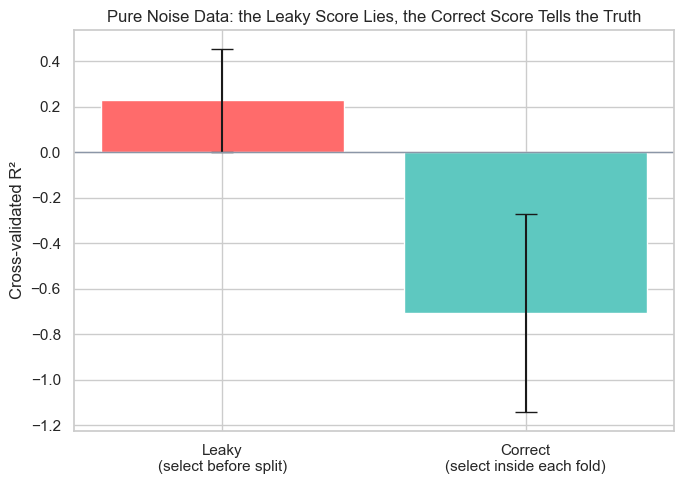

In [45]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(['Leaky\n(select before split)', 'Correct\n(select inside each fold)'],
       [leaky_scores.mean(), correct_scores.mean()],
       yerr=[leaky_scores.std(), correct_scores.std()],
       color=['#ff6b6b', '#5ec8c0'], capsize=8)
ax.axhline(0, color='#8b96a7', linewidth=1)
ax.set_ylabel('Cross-validated R²')
ax.set_title('Pure Noise Data: the Leaky Score Lies, the Correct Score Tells the Truth')
plt.tight_layout()
plt.show()

**Read this result carefully -- it's the single most important result in this notebook.** The data
is *pure noise*; the true R² of any honest model here is 0. The leaky approach reports a
misleadingly optimistic R², purely because selecting the "best" 10 out of 200 random columns using
the full dataset will always find a handful that happen to correlate with `y` by chance -- with
200 candidates, chance alone guarantees some will look good. The correct, nested approach reports a
score near zero, correctly reflecting that there's nothing real to find. **This is exactly why
feature selection belongs inside the Pipeline, not before the train/test split** -- Part 7 makes
that the default going forward.

---
## Part 7 -- Feature Selection Inside a Proper Pipeline
Back to the real housing dataset. Compare a full-feature model against a feature-selected model,
both evaluated the honest way -- selection re-fit inside every cross-validation fold.

In [46]:
X_train, X_test, y_train, y_test = train_test_split(housing[all_features], housing['price'],
                                                      test_size=0.2, random_state=42)

full_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', LinearRegression()),
])

selected_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('select', SelectFromModel(Lasso(alpha=5000, max_iter=20000))),
    ('model', LinearRegression()),
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

for name, pipe in [('All features', full_pipe), ('Lasso-selected features', selected_pipe)]:
    start = time.perf_counter()
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='r2')
    elapsed = time.perf_counter() - start
    print(f'{name:<26}  CV R²: {scores.mean():.3f} ± {scores.std():.3f}   ({elapsed*1000:.0f} ms total)')

All features                CV R²: 0.883 ± 0.044   (35 ms total)
Lasso-selected features     CV R²: 0.872 ± 0.038   (38 ms total)


In [47]:
# Fit the winning approach on the full training set, evaluate ONCE on the held-out test set.
selected_pipe.fit(X_train, y_train)
n_kept = selected_pipe.named_steps['select'].get_support().sum()
n_total = len(feature_names_full)

test_r2 = selected_pipe.score(X_test, y_test)
print(f'Features kept: {n_kept} of {n_total}')
print(f'Test R² with selected features: {test_r2:.3f}')

Features kept: 6 of 19
Test R² with selected features: 0.886


**The payoff:** comparable (often nearly identical) predictive performance, using a fraction of
the original features -- meaning a simpler, cheaper, more interpretable model, with the noise
columns and the redundant duplicate correctly identified and dropped along the way. Nothing about
this result depended on us knowing the ground truth in advance; the pipeline found it honestly,
using only the training data at every step.

---
## Summary

| Part | Technique | Key operation |
|---|---|---|
| **Filter -- variance** | Drop near-constant columns | `VarianceThreshold(threshold=...)` |
| **Filter -- relevance** | Score each feature against the target | `SelectKBest(f_regression, k=...)`, `f_classif`, `mutual_info_*` |
| **Filter -- redundancy** | Drop highly correlated feature pairs | `.corr()` + a threshold (e.g. 0.9) |
| **Wrapper** | Eliminate the weakest feature repeatedly | `RFE(estimator, n_features_to_select=...)` |
| **Wrapper (auto count)** | Let CV choose how many features | `RFECV(estimator, cv=...)` |
| **Embedded -- Lasso** | Selection as a side effect of the L1 penalty | `SelectFromModel(Lasso(alpha=...))` |
| **Embedded -- trees** | Selection from importance scores | `SelectFromModel(RandomForestRegressor())` |
| **The leakage trap** | Select using training data only | Put the selector **inside** the `Pipeline`, never before `train_test_split` |
| **Not the same as** | Feature Engineering creates columns; PCA blends columns | Feature Selection only ever *keeps a subset* |

---

**Next lecture:** Cross-Validation formalizes the `cv=KFold(...)` object used throughout this
notebook -- what it's actually doing, how to choose `k`, and how it extends beyond feature
selection to tuning any hyperparameter honestly.